In [ ]:
!pip install hsemotion

# Обработка изображений

In [ ]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import cv2
from hsemotion.facial_emotions import HSEmotionRecognizer
import torch
from tqdm import tqdm
import time

In [ ]:
emotions = ['Anger', 'Disgust', 'Fear', 'Happiness', 'Sadness', 'Surprise', 'Neutral']
meta_df = pd.read_csv('metadata_processed.csv')
face_df = pd.read_csv('icml_face_data.csv')
#test_df = pd.read_csv('test.csv')

In [ ]:
face_df.columns = ['label', ' Usage', 'pixels']

In [ ]:
face_df = face_df.rename(columns={"emotion":"label"})
face_df['emotion'] = face_df['label'].apply(lambda x: emotions[int(x)])

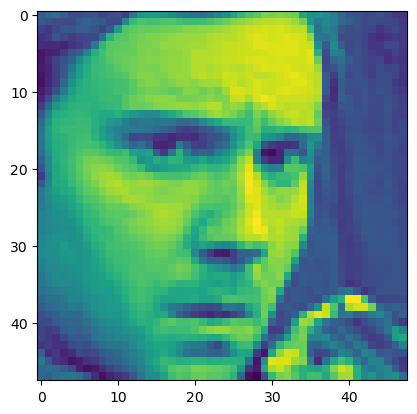

Anger


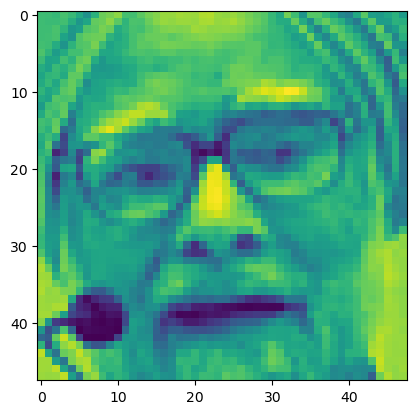

Anger


In [ ]:
for i in range(2):
    id = i
    image = np.reshape(np.array(face_df.pixels[id].split(' ')).astype(int),(48,48))
    plt.imshow(image)
    plt.show()
    print(face_df.emotion[id])

In [ ]:
face_df.shape[0]

35887

In [ ]:
use_cuda = torch.cuda.is_available()
device = 'cuda' if use_cuda else 'cpu'

In [ ]:
from hsemotion.facial_emotions import HSEmotionRecognizer
model_name='enet_b0_8_best_afew'
fer=HSEmotionRecognizer(model_name=model_name,device=device)

C:\Users\Operator\.hsemotion\enet_b0_8_best_afew.pt Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=warn)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
id = 3
face_img = np.reshape(np.array(face_df.pixels[id].split(' ')).astype(np.uint8),(48,48))
color_img = cv2.cvtColor(face_img, cv2.COLOR_GRAY2RGB)

In [ ]:
id = 4
face_img4 = np.reshape(np.array(face_df.pixels[id].split(' ')).astype(np.uint8),(48,48))
color_img4 = cv2.cvtColor(face_img4, cv2.COLOR_GRAY2RGB)

In [ ]:
plt.imshow(color_img)
plt.show()

In [ ]:
emotion,scores=fer.predict_emotions(color_img,logits=True)
print(emotion,scores)

plt.figure(figsize=(3, 3))
plt.axis('off')
plt.imshow(face_img)
plt.title(emotion)

In [ ]:
face_img_list = [color_img, color_img4]

emotions,scores=fer.predict_multi_emotions(face_img_list,logits=False)
features=fer.extract_multi_features(face_img_list)

In [ ]:
emotions

In [ ]:
face_df.columns

In [ ]:
def image_transform(image):
    face_img= np.reshape(np.array(image.split(' ')).astype(np.uint8),(48,48))
    return cv2.cvtColor(face_img, cv2.COLOR_GRAY2RGB)

# Точность моделей HSEmotion


In [ ]:
models = ['enet_b0_8_va_mtl']
#, 'enet_b2_8', 'enet_b0_8_best_afew', 'enet_b0_8_best_vgaf'

In [ ]:
def count_acc(actual, predict):
    count = 0
    for i in range(len(actual)):
        if actual[i] == predict[i]:
            count += 1
    accuracy = count / len(actual)
    return accuracy

In [ ]:
actual = face_df['emotion'].tolist()

In [ ]:
def get_emotion(id):
  face_img = np.reshape(np.array(face_df.pixels[id].split(' ')).astype(np.uint8),(48,48))
  color_img = cv2.cvtColor(face_img, cv2.COLOR_GRAY2RGB)
  emotion,scores=fer.predict_emotions(color_img,logits=True)
  return emotion

In [ ]:
res_acc = {}
res_acc['accuracy'] = {}
res_acc['accuracy neg emotions'] = {}

In [ ]:
num_id = 60
#face_df.shape[0]
# hsemotion  - 3123 сек, 0.57

In [ ]:
for model in models:
    prediction = []
    fer=HSEmotionRecognizer(model_name=model, device=device)
    start_time = time.time()
    for i in range(num_id):
        prediction.append(get_emotion(i))
    end_time = time.time()
    execution_time = end_time - start_time
    print("Время выполнения: %s секунд" % execution_time)
    res_acc['accuracy']['model'] = count_acc(prediction, actual)
    #res_acc['accuracy neg emotions']['model'] = count_neg_acc(actual, prediction)
    print(res_acc['accuracy']['model'])

In [ ]:
face_df['img'] = face_df['pixels'].apply(lambda x : image_transform(x))

In [ ]:
face_list = face_df['img'].tolist()

In [ ]:
start_time = time.time()
emotions,scores=fer.predict_multi_emotions(face_list[0:num_id],logits=False)
end_time = time.time()
execution_time = end_time - start_time
print("Время выполнения: %s секунд" % execution_time)

# Точность моделей OpenFace


In [ ]:
!pip install deepface

In [ ]:
from deepface import DeepFace

In [ ]:
res = DeepFace.analyze(img_path = color_img4, enforce_detection = False, actions=['emotion'])
res

In [ ]:
res[0]['dominant_emotion']

In [ ]:
deepface_emotions = []
start_time = time.time()
for id in range(num_id):
    img = image_transform(face_df.pixels[id])
    demography = DeepFace.analyze(img_path = img, enforce_detection = False, actions=['emotion'])
    deepface_emotions.append(demography[0]['dominant_emotion'])
end_time = time.time()
execution_time = end_time - start_time
print("Время выполнения: %s секунд" % execution_time)

In [ ]:
print(len(deepface_emotions))

In [ ]:
deepface_emotions[0]

In [ ]:
actual

In [ ]:
deepface_emotions

In [ ]:
word_map = {
    'happy': 'Happiness',
    'angry': 'Anger',
    'sad': 'Sadness',
    'fear': 'Fear',
    'neutral': 'Neutral',
    'surprise': 'Surprise',
    'disgust': 'Disgust'
}

In [ ]:
deepface_emotions = [word_map.get(word, word) for word in deepface_emotions]
deepface_emotions

In [ ]:
prediction

In [ ]:
count_acc(prediction, actual) # Hsemotion цикл

In [ ]:
count_acc(deepface_emotions, actual) # Hsemotion батч

In [ ]:
count_acc(emotions, actual) #DeepFace

# Real time video

In [ ]:
faceCascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
cap = cv2.VideoCapture(0)
font = cv2.FONT_HERSHEY_SIMPLEX

#if not cap.isOpened():
#    cap = cv2.VideoCapture(0)
#if not cap.isOpened():
#    raise IOError('It is not possible to open webcam')

while True:
    ret, frame = cap.read()
    result = DeepFace.analyze(frame, actions = ['emotion'], enforce_detection = False)
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = faceCascade.detectMultiScale(gray, 1.1, 4)
    X, Y = 50, 50
    for(x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (135, 206, 250), 2)
        X = x + 10
        Y = y - 5
    cv2.putText(frame, result[0]['dominant_emotion'], (X, Y), font, 1, (135, 206, 250), 2, cv2.LINE_4)
    cv2.imshow('Real time video', frame)
    if cv2.waitKey(10) == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

Action: emotion:   0%|                                                                           | 0/1 [00:00<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
cap.release()
cv2.destroyAllWindows()

# Другой датасет

In [ ]:
from torchvision.datasets import ImageFolder

In [ ]:
dataset = ImageFolder('C:\\Users\\Operator\\Desktop\\Project\\icml_face_data.csv\\dataset')

In [ ]:
dataset[1][1]

0

In [ ]:
def transform_img(img):
    gray_image = img.convert('L')
    resized_image = gray_image.resize((48, 48))
    return np.array(resized_image)

In [ ]:
emotions_list = [img[1] for img in dataset]

In [ ]:
img_list = [np.array(img[0]) for img in dataset]

In [ ]:
num_id = 1000

In [ ]:
models = ['enet_b0_8_best_vgaf',
'enet_b0_8_best_afew',
'enet_b0_8_va_mtl',
'enet_b2_8',
'enet_b2_7']

In [ ]:
for model in models:
    fer=HSEmotionRecognizer(model_name=model, device=device)
    prediction = []
    start_time = time.time()
    for i in range(len(img_list)):
        emotion,scores=fer.predict_emotions(img_list[i],logits=True)
        prediction.append(emotion)
    end_time = time.time()
    execution_time = end_time - start_time
    print("Время выполнения: %s секунд" % execution_time)
    print(count_acc(emotions_list, prediction))

C:\Users\Operator\.hsemotion\enet_b0_8_best_vgaf.pt Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=warn)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [ ]:
img_list[0].shape

(224, 224, 3)

In [ ]:
emotions

['Anger',
 'Anger',
 'Anger',
 'Fear',
 'Disgust',
 'Anger',
 'Happiness',
 'Anger',
 'Anger',
 'Anger']

In [ ]:
prediction = []
start_time = time.time()
for i in range(len(img_list)):
    emotion,scores=fer.predict_emotions(img_list[i],logits=True)
    prediction.append(emotion)
end_time = time.time()
execution_time = end_time - start_time
print("Время выполнения: %s секунд" % execution_time)

Время выполнения: 425.43591237068176 секунд


In [ ]:
unique_values = list(set(prediction))
print(unique_values)

['Anger', 'Happiness', 'Sadness', 'Disgust', 'Contempt', 'Fear', 'Surprise', 'Neutral']


In [ ]:
word_map = {
     4: 'Happiness',
     0: 'Anger',
     1: 'Contempt',
     6: 'Sadness',
     3: 'Fear',
     5: 'Neutral',
     7: 'Surprise',
     2: 'Disgust'
}

In [ ]:
emotions_list = [word_map.get(word, word) for word in emotions_list]
emotions_list

['Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',
 'Anger',


In [ ]:
count_acc(emotions_list, prediction)

0.6272040302267002

In [ ]:
deepface_emotions = []
start_time = time.time()
for i in range(len(img_list)):
    img = img_list[i]
    demography = DeepFace.analyze(img_path = img, enforce_detection = False, actions=['emotion'])
    deepface_emotions.append(demography[0]['dominant_emotion'])
end_time = time.time()
execution_time = end_time - start_time
print("Время выполнения: %s секунд" % execution_time)

Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.77it/s]


Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.66it/s]


Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.54it/s]


Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.13it/s]


Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 13.42it/s]


...

Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  7.58it/s]


Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  7.31it/s]


Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  7.16it/s]


Action: emotion: 100%|███████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  7.97it/s]


Время выполнения: 906.514044046402 секунд


In [ ]:
unique_values = list(set(deepface_emotions))
print(unique_values)

['neutral', 'disgust', 'angry', 'sad', 'happy', 'fear', 'surprise']


In [ ]:
word_map = {
    'happy': 'Happiness',
    'angry': 'Anger',
    'sad': 'Sadness',
    'fear': 'Fear',
    'neutral': 'Neutral',
    'surprise': 'Surprise',
    'disgust': 'Disgust'
}

In [ ]:
deepface_emotions = [word_map.get(word, word) for word in deepface_emotions]

In [ ]:
count_acc(deepface_emotions, emotions_list)

0.4202950701691256

In [ ]:
first_index = emotions_list.index('Contempt')
last_index = emotions_list.index('Disgust')
print(first_index, last_index)

890 1098


In [ ]:
e_list =  emotions_list[:first_index] + emotions_list[last_index:]
h_list =  prediction[:first_index] + prediction[last_index:]
d_list =  deepface_emotions[:first_index] + deepface_emotions[last_index:]

In [ ]:
count_acc(h_list, e_list)

0.6433644859813085

In [ ]:
count_acc(d_list, e_list)

0.4366355140186916